# 用路径损耗等值线曲面绘制蜂窝基站覆盖地图

## 执行摘要

某电信无线网络规划团队将单个宏蜂窝基站周围的下行**路径损耗曲面**渲染为二维覆盖地图。本示例使用带对数正态阴影衰落的对数距离传播模型，构建一个100点的测量网格（10x10个网格单元，覆盖10公里x10公里的服务区域，基站位于中心），并用 **PROC SGPLOT HEATMAPPARM** 绘制填色等值线曲面，配合渐变色标和基站参考线。

在执行的网格上，路径损耗范围从基站附近明亮盆地的**50.4 dB**到远角的**90.0 dB**，平均为**75.6 dB**。按损耗对每个网格单元分类，得到**38个强覆盖、61个可用、1个弱覆盖**单元；唯一的弱覆盖单元位于**(9.5, 9.5)公里处——基站对角线正对面的角落——损耗为89.97 dB**，这是规划人员在决定是否新增小基站之前会标记出的唯一覆盖盲区。

> **关于所用过程的说明。** 在 SAS 中，绘制等值线图的经典工具是 `PROC GCONTOUR`。Jenner 能解析 GCONTOUR 并生成正确的绘图规格，但其光栅渲染器尚未实现等值线几何图形的绘制（图像会返回空白）；该缺陷已作为回归测试 `tests/400922_nb_gcontour_empty_render` 予以记录。为了确保本示例基于真实渲染的图形，我们改用 SAS 兼容的等价方案——带 `HEATMAPPARM` 语句的 `PROC SGPLOT`——它以填色等值线单元加渐变图例的形式渲染同样的网格化 (x, y, z) 曲面。

## 数据来源

**模拟数据集：`pathloss_grid`**（100行——10x10网格）

| 变量 | 类型 | 单位 | 说明 |
|----------|------|-------|-------------|
| `east_km` | 数值 | 公里 | 网格单元中心的东向坐标（0.5至9.5）；x轴 |
| `north_km` | 数值 | 公里 | 网格单元中心的北向坐标（0.5至9.5）；y轴 |
| `path_loss` | 数值 | dB | 下行路径损耗 = 58 + 30 log10(距离) + 阴影衰落；响应变量（z） |
| `zone` | 字符(8) | — | 覆盖等级：强（<=75）、可用（<=88）、弱（>88） |

基站位于网格中心**(5, 5)公里**处。路径损耗随距基站距离的以10为底的对数增长；一个 `3*rand("normal")` 的阴影项（种子80211）注入对数正态衰落，使等值线并非完美的同心圆。10x10网格的规模确保整个曲面刚好落在100条观测以内。

## 步骤1 — 生成测量网格

我们布设一个1公里间距的网格单元中心网格，并用**对数距离模型** `PL = 58 + 30 log10(d)` 计算路径损耗，其中 `d` 是到位于(5, 5)公里处基站的距离。一个 `rand("normal")` 阴影衰落项复现了真实路测中观察到的变异性。每个网格单元被分类到一个覆盖`zone`（区域）。`call streaminit` 固定随机种子以保证可重复性。

In [1]:
数据 pathloss_grid;
   调用 streaminit(80211);
   长度 zone $12;
   tower_x = 5.0;  tower_y = 5.0;
   循环 ix = 1 到 10;
      循环 iy = 1 到 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         如果      path_loss <= 75 那么 zone = "强";
         否则 如果 path_loss <= 88 那么 zone = "可用";
         否则                         zone = "弱";
         输出;
      结束;
   结束;
   删除 ix iy tower_x tower_y DIST shadow;
   标签 east_km   = "东向坐标（公里）"
         north_km  = "北向坐标（公里）"
         path_loss = "路径损耗（dB）";
运行;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## 步骤2 — 汇总曲面

在绘图之前，我们先对曲面进行量化。`PROC MEANS` 报告路径损耗的动态范围，`PROC FREQ` 统计100个网格单元在三个覆盖等级间的分布——即执行摘要中引用的数字。

In [2]:
ODS GRAPHICS OFF;

过程 均值 数据=pathloss_grid MIN MAX mean maxdec=1;
   变量 path_loss;
运行;

过程 频率 数据=pathloss_grid ORDER=频率;
   TABLES zone / nocum;
运行;

                                                  The MEANS Procedure

 Variable   Label                    Minimum     Maximum        Mean
 -------------------------------------------------------------------
 path_loss  路径损耗（dB）                    50.4        90.0        75.6
 -------------------------------------------------------------------

                                                   The FREQ Procedure

zone      Frequency    Percent
-------------------------------
可用               61     61.00
强                38     38.00
弱                 1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## 步骤3 — 定位覆盖盲区

按路径损耗降序排序，将信号最弱的网格单元排在最前面。这些是规划人员需要检查的候选**盲区**：接收信号最弱、因而最容易掉话或吞吐量不佳的网格单元。

In [3]:
过程 排序 数据=pathloss_grid out=weakest;
   按照 DESCENDING path_loss;
运行;

过程 打印 数据=weakest(obs=6) noobs 标签;
   变量 east_km north_km path_loss zone;
运行;


                东向坐标（公里）                  北向坐标（公里）              路径损耗（dB）    zone
------------------------  ------------------------  --------------------  ------
                     9.5                       9.5         89.9728891641  弱
                     9.5                       0.5         85.9296978639  可用
                     6.5                       0.5         84.5845683025  可用
                     0.5                       0.5         84.5118930355  可用
                     8.5                       0.5         84.1534148341  可用
                     9.5                       8.5         83.7015943773  可用

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## 步骤4 — 绘制路径损耗等值线曲面

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` 为每个网格点渲染一个按路径损耗着色的填色单元——即覆盖足迹的填色等值线图。`COLORMODEL=` 列表定义了一个蓝到红的发散渐变（蓝色=低损耗=强信号；红色=高损耗=弱信号）；`GRADLEGEND` 附加dB色标。虚线 `REFLINE` 标出东向坐标5和北向坐标5处的基站位置。

                                                      下行路径损耗曲面（dB）                                                      
                                              单个宏蜂窝基站位于10x10公里网格的(5, 5)公里处                                              




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to 下行路径损耗曲面（dB）.
NOTE: Option TITLE2 changed to 单个宏蜂窝基站位于10x10公里网格的(5, 5)公里处.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


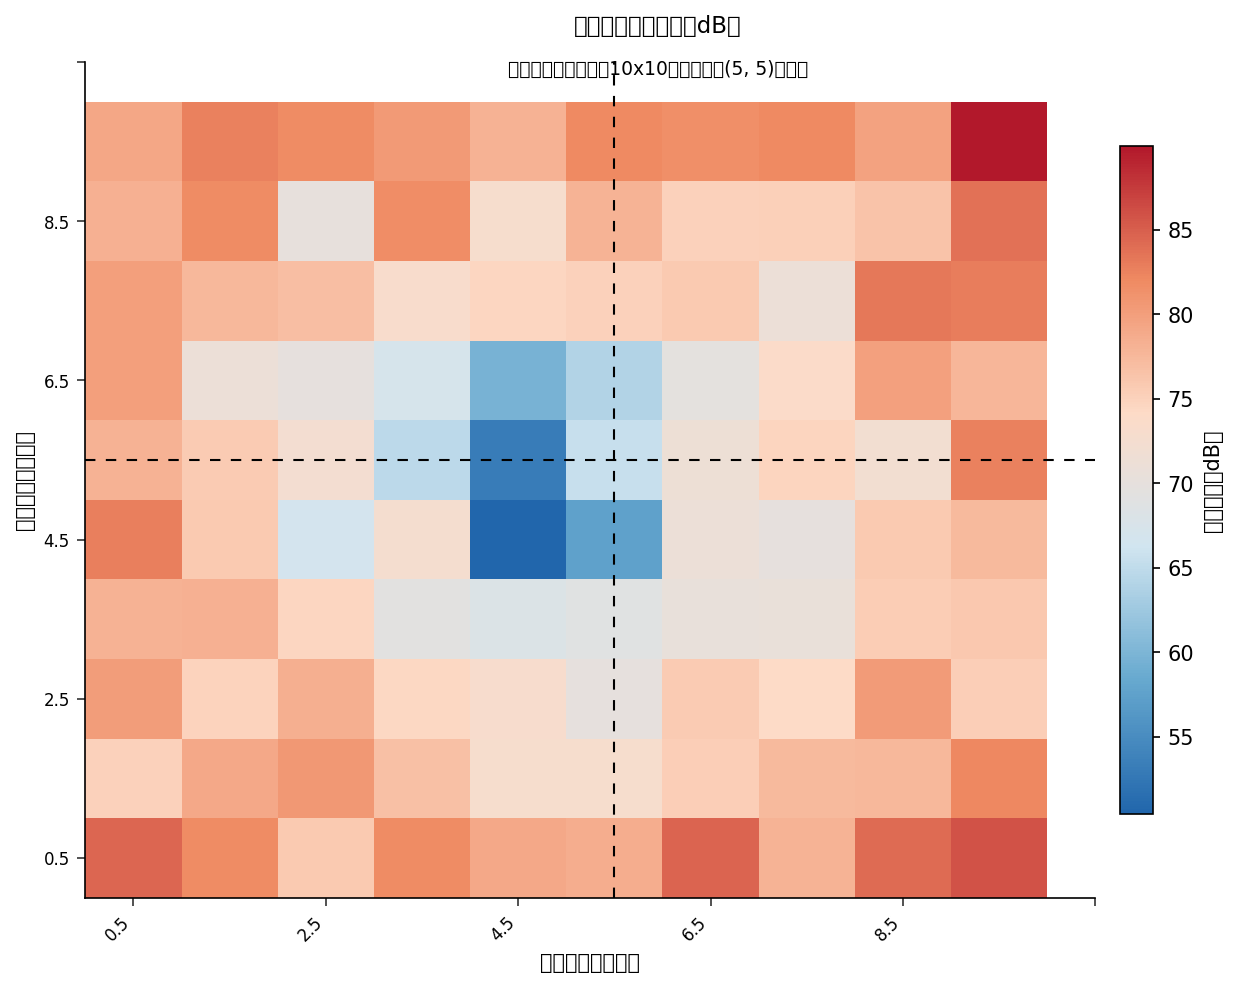

In [4]:
ODS GRAPHICS ON;
标题 "下行路径损耗曲面（dB）";
title2 "单个宏蜂窝基站位于10x10公里网格的(5, 5)公里处";

过程 SGPLOT 数据=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / 标题="路径损耗（dB）";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) 标签="东向坐标（公里）";
   YAXIS VALUES=(0 2 4 6 8 10) 标签="北向坐标（公里）";
运行;

标题; title2;

## 步骤5 — 覆盖等级分布

汇报材料还需要一个总览式的拆分：覆盖足迹中强、可用、弱各占多大比例。对 `zone` 分类做一个 `VBAR` 图即可一目了然，并与上方的等值线曲面相呼应。

                                                         覆盖等级分布                                                         




NOTE: Option TITLE changed to 覆盖等级分布.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


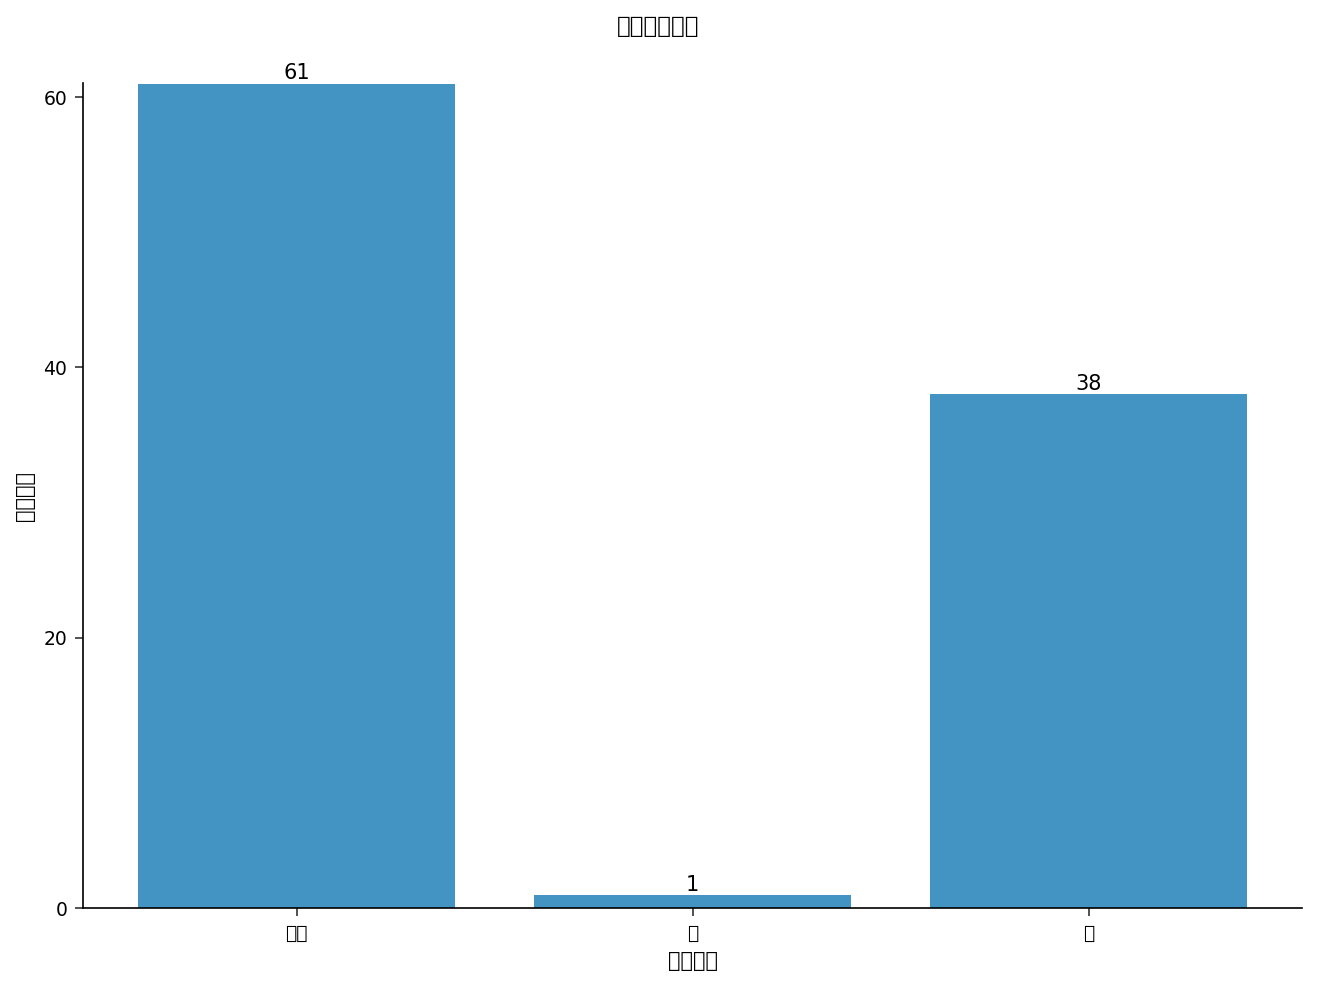

In [5]:
标题 "覆盖等级分布";

过程 SGPLOT 数据=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS 标签="覆盖等级";
   YAXIS 标签="网格数量" VALUES=(0 20 40 60);
运行;

标题;

## 结果解读

等值线曲面印证了预期的传播物理规律。路径损耗在**(5, 5)公里基站周围的紧凑蓝色盆地**中最低——即接收信号最好的强覆盖区——并随对数距离向四角递增。由于我们注入了对数正态阴影衰落，各条带并非同心圆；边界处参差不齐的红色单元正是阴影衰落造成的边缘效应。

可操作的结论是**位于(9.5, 9.5)公里处的唯一弱覆盖单元（89.97 dB）**，它是基站对角线正对面的角落，也是唯一超过88 dB设计阈值的点。在100个单元中有**61个可用、仅1个弱覆盖**的情况下，该宏蜂窝基站对其服务区域的覆盖良好；只有在这个盲区恰好覆盖了已知的需求热点时，**新增小基站或将扇区朝东北角重新倾斜**才有必要。等值线曲面是可直接用于汇报的总结图；覆盖等级柱状图则给出了容量规划人员向上汇报时所需的单一数字拆分。